In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def display(img, cmap = None):
    fig = plt.figure(figsize=(10,10))
    ax = fig.add_subplot(111)
    ax.imshow(img, cmap = cmap)

## Face detection

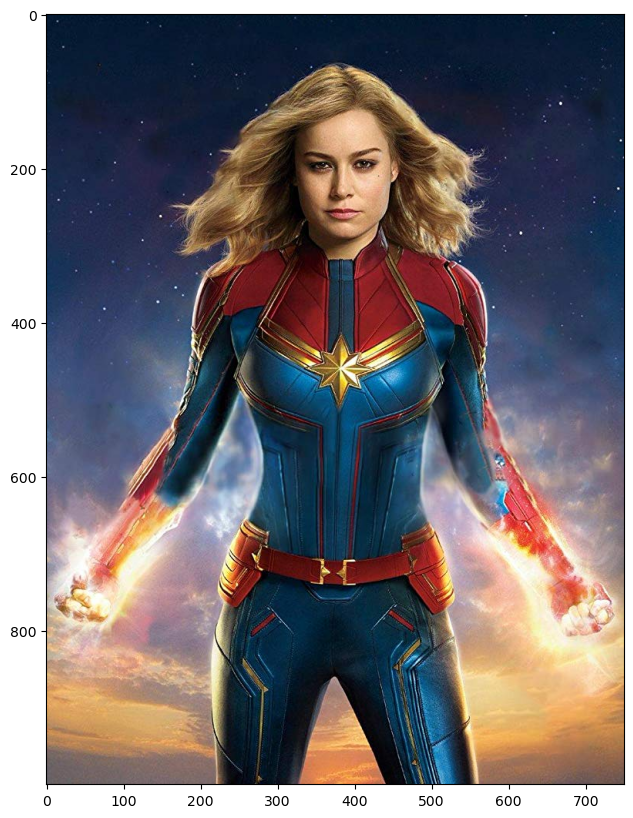

In [3]:
cap_mar = cv2.imread('captin_marvel.jpg')
cap_mar = cv2.cvtColor(cap_mar, cv2.COLOR_BGR2RGB)
display(cap_mar)

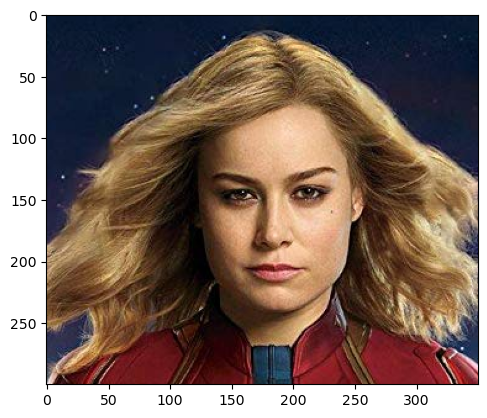

In [4]:
# fining roi
roi = cap_mar[50:350, 200:550]
plt.imshow(roi)

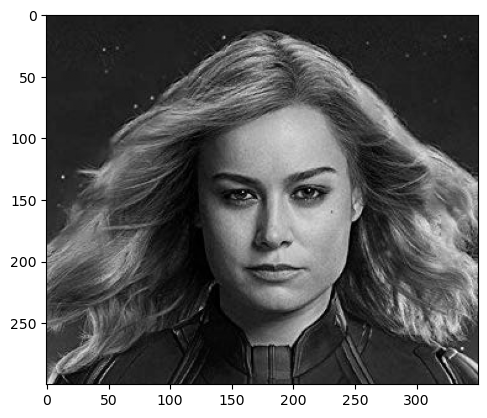

In [5]:
roi = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
plt.imshow(roi, cmap = 'gray')

In [6]:
# load Cascade filter
face_cascade = cv2.CascadeClassifier('C:/Users/ajant/Downloads/ProgNxt/Day 12/haarcascade_frontalface_default.xml')

In [7]:
def detect_face(img):
    img_copy = img.copy()
    face_rects = face_cascade.detectMultiScale(img_copy, scaleFactor = 1.1, minNeighbors = 3)
    for (x,y,w,h) in face_rects:
        cv2.rectangle(img_copy, (x,y), (x+w, y+h), (255,255,255), 3)
    return img_copy

(np.float64(-0.5), np.float64(349.5), np.float64(299.5), np.float64(-0.5))

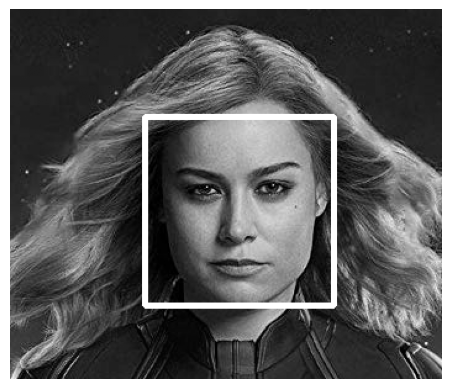

In [8]:
# detect the face
roi_detected= detect_face(roi)
plt.imshow(roi_detected, cmap = 'gray')
plt.axis('off')

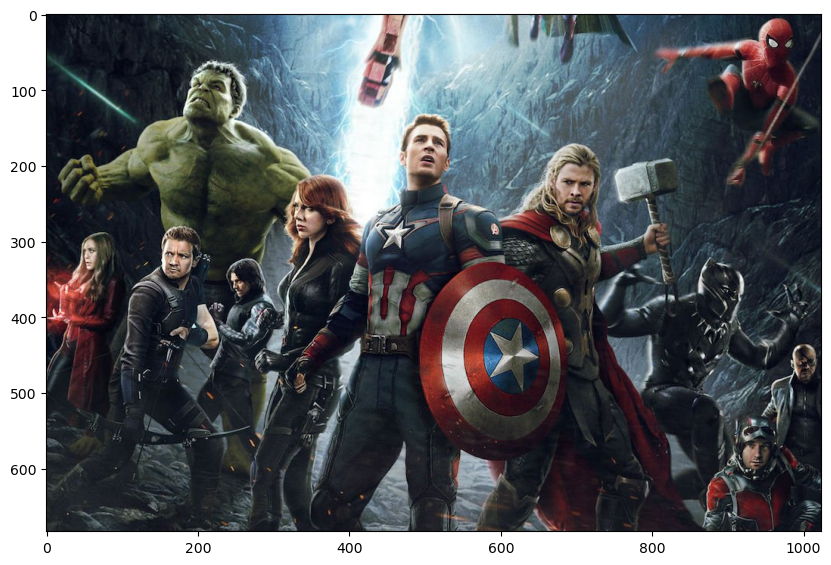

In [9]:
aveng = cv2.imread('avengers.jpg')
aveng = cv2.cvtColor(aveng, cv2.COLOR_BGR2RGB)
display(aveng)

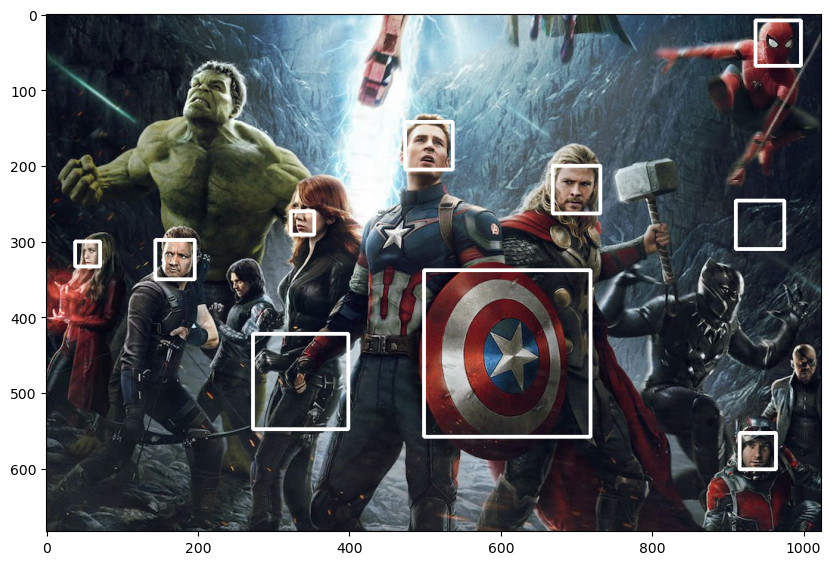

In [10]:
detected_aveng = detect_face(aveng)
display(detected_aveng)

## What about your face????

In [12]:
capture = cv2.VideoCapture(0)
while True:
    ret, frame = capture.read(0)
    frame = detect_face(frame)
    cv2.imshow("Video face Detection", frame)
    c = cv2.waitKey(1)
    if c==27:
        break
capture.release()
cv2.destroyAllWindows()